In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('sales_data.csv')
df.head(10)


,Date,Product,Quantity,Price
0,2024-01-05,Laptop,2.0,750.0
1,2024-01-12,Monitor,3.0,200.0
2,2024-01-18,Keyboard,5.0,45.0
3,2024-01-22,Mouse,8.0,25.0
4,2024-02-03,Laptop,1.0,750.0
5,2024-02-07,Monitor,2.0,200.0
6,2024-02-11,Keyboard,4.0,45.0
7,2024-02-15,Mouse,6.0,25.0
8,2024-02-20,Headphones,7.0,80.0
9,2024-02-25,Laptop,2.0,750.0


In [3]:
print("Dataset Info:")
df.info()
print("\nMissing Values:")
df.isnull().sum()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      23 non-null     object 
 1   Product   23 non-null     object 
 2   Quantity  22 non-null     float64
 3   Price     21 non-null     float64
dtypes: float64(2), object(2)
memory usage: 868.0+ bytes

Missing Values:


,0
Date,0
Product,0
Quantity,1
Price,2


In [4]:
df['Price'].fillna(df['Price'].mean(), inplace=True)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df.drop_duplicates(inplace=True)
df['Revenue'] = df['Quantity'] * df['Price']
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df.head()


/tmp/ipykernel_7686/1330048145.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(df['Price'].mean(), inplace=True)
/tmp/ipykernel_7686/1330048145.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,Date,Product,Quantity,Price,Revenue,Month
0,2024-01-05,Laptop,2.0,750.0,1500.0,January
1,2024-01-12,Monitor,3.0,200.0,600.0,January
2,2024-01-18,Keyboard,5.0,45.0,225.0,January
3,2024-01-22,Mouse,8.0,25.0,200.0,January
4,2024-02-03,Laptop,1.0,750.0,750.0,February


In [5]:
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print("Top 5 Products by Revenue:")
print(product_revenue.head())

Top 5 Products by Revenue:
Product
Laptop        10500.000000
Monitor        3018.095238
Headphones     2196.190476
Keyboard        900.000000
Mouse           825.000000
Name: Revenue, dtype: float64


In [6]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
print("Monthly Sales Trend:")
print(monthly_revenue)

Monthly Sales Trend:
Month
February    4158.095238
January     3761.190476
March       9520.000000
Name: Revenue, dtype: float64


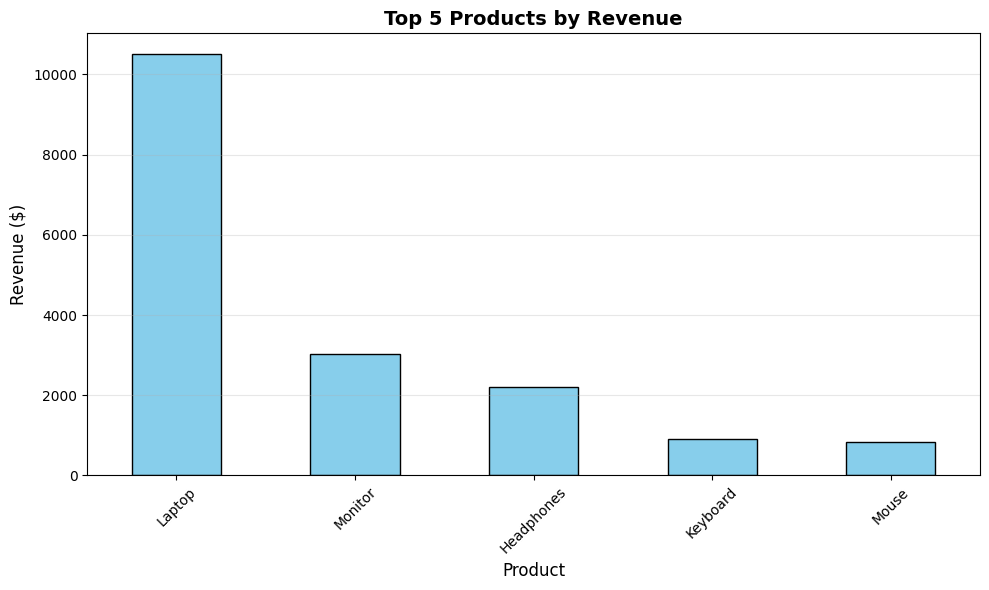

In [7]:
plt.figure(figsize=(10,6))
product_revenue.head(5).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 5 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

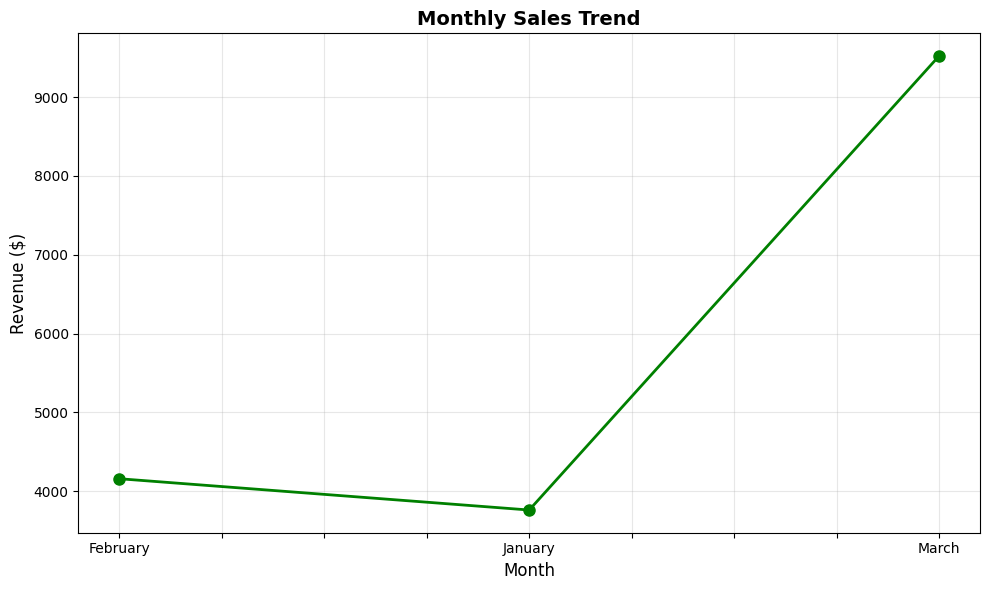

In [8]:
plt.figure(figsize=(10,6))
monthly_revenue.plot(kind='line', marker='o', color='green', linewidth=2, markersize=8)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()